<hr/>

# [Generalized Linear Mixed Models](https://donnievin.github.io/ASDA_2/)
By: **Donovan Vincent Jr** - dvincen9@jh.edu <br/>
Adapted From: **Dr. Sergey Kushnarev's ASDA II** <br/>
Estimated Workthrough Time: **90 mins**

<hr/>

<h1><font color="blue">Fitting GLM and Inference</font></h1>

Topics: 
* Fisher Scoring vs Newton Raptison
* Model / Variable Selection
* Measuring Predictive Power: LL, AIC, BIC
* Effects of Collinearity (Ill-conditioned)
* Example 1: Satellite Crabs
* Example 2: Florida House Prices

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import scipy.stats as stats
import statsmodels.api as sm # https://www.statsmodels.org/stable/datasets/index.html
import statsmodels.formula.api as smf

# <font color='lightblue'> Fisher Scoring vs Newton Raptison </font>

> Setup

$Y_i \sim Poisson(\mu_i)$. Using the canonical link function, we see: 

<div align="center">

$$
\theta_i = \eta_i
$$

$$
log(\mu_i) = \sum_{j=1}^p X_{ij} \beta_j
$$

$$
log(\mu_i) = \beta_0 + \beta_1 X_1
$$

</div>

---

> Synthetic Data


We will generate some random data from the equation 

<div align="center">

$$
log(\mu_i) = 1 + 0.5 X_1
$$

</div>


--- 



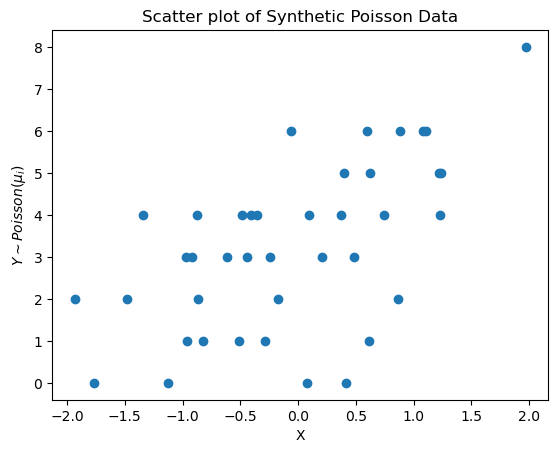

In [22]:
np.random.seed(31100)

n = 40
X = np.random.normal(size=n) # Design matrix (nx1)

beta0, beta1 = 1, 0.5 # Parameter vector we are trying to recover with GLM

# Calculate mu_i using the link function g(mu_i) = beta0 + beta1 * X1, then generate Y_is ~ Pois(mu_i)
mu_i = np.exp(beta0 + beta1*X) # 
Y = np.random.poisson(lam=mu_i)

plt.scatter(X, Y)
plt.title("Scatter plot of Synthetic Poisson Data")
plt.xlabel("X")
plt.ylabel(r"$Y \sim Poisson(\mu_i)$")
plt.show()

In [17]:
# Put into a pandas DataFrame (needed for formula API)
Synthetic_df = pd.DataFrame({
    "Y": Y,
    "X": X,
})

# <font color='lightblue'> Model / Variable Selection </font>

We can start with a simple model, which fits only the mean of the data:


<div align="center">

$$
log(\mu_i) = \beta_0
$$

</div>

<font color='purple'> Note, we need to exponentiate the fitted parameter to get back the mean! </font>

In [19]:
intercept_only_fit = smf.glm(
    formula = "Y~1",
    data = Synthetic_df,
    family = sm.families.Poisson()
).fit()

print(intercept_only_fit.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:                      Y   No. Observations:                   40
Model:                            GLM   Df Residuals:                       39
Model Family:                 Poisson   Df Model:                            0
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -84.036
Date:                Sun, 03 May 2026   Deviance:                       58.522
Time:                        19:49:38   Pearson chi2:                     47.2
No. Iterations:                     4   Pseudo R-squ. (CS):              0.000
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      1.1787      0.088     13.439      0.0

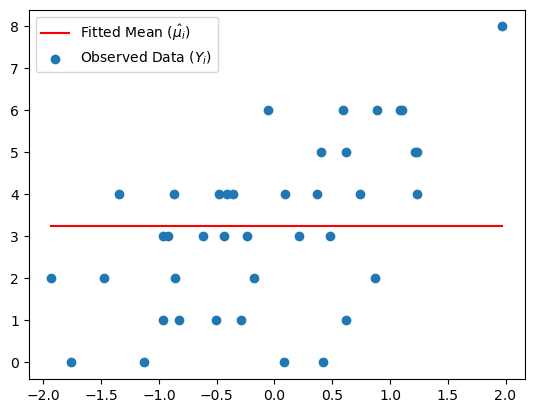

In [ ]:
# Need to clean up or else it will be a zig-zag function
df_sorted = Synthetic_df.sort_values("X") 
Y_predicted_null = intercept_only_fit.predict(df_sorted) # Does the exponentiation for us!

plt.scatter(X, Y, label=r'Observed Data ($Y_i$)')
plt.plot(df_sorted["X"], Y_predicted_null, color='red', label=r'Fitted Mean ($\hat{\mu_i}$)')
plt.legend()
plt.show()

# <font color='lightblue'> Measuring Predictive Power </font>

We can now fit log-linear GLM model to the data and see the improvement. The equation being fit is:


<div align="center">

$$
log(\mu_i) = \beta_0 + \beta_1 X_1
$$

</div>

<font color='purple'> Note, we again need to exponentiate to get the mean </font>

In [35]:
Poisson_GLM_fit = smf.glm(
    formula="Y~X",
    data = Synthetic_df,
    family = sm.families.Poisson()
).fit()

print(Poisson_GLM_fit.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:                      Y   No. Observations:                   40
Model:                            GLM   Df Residuals:                       38
Model Family:                 Poisson   Df Model:                            1
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -75.826
Date:                Sun, 03 May 2026   Deviance:                       42.100
Time:                        20:21:05   Pearson chi2:                     31.6
No. Iterations:                     4   Pseudo R-squ. (CS):             0.3367
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      1.1383      0.091     12.450      0.0

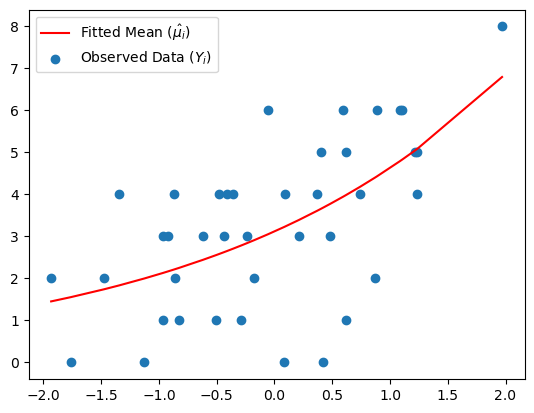

In [ ]:
Y_predicted_GLM = Poisson_GLM_fit.predict(df_sorted) # Does the exponentiation for us!

plt.scatter(X, Y, label=r'Observed Data ($Y_i$)')
plt.plot(df_sorted["X"], Y_predicted_GLM, color='red', label=r'Fitted Mean ($\hat{\mu_i}$)')
plt.legend()
plt.show()

# <font color='lightblue'> Effects of Collinearity </font>

## Visualizing both fits

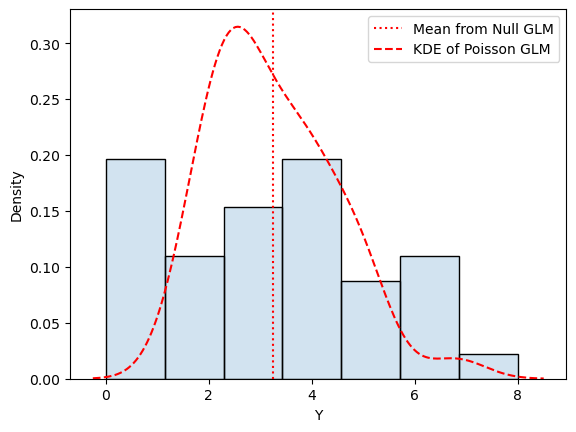

In [69]:
sns.histplot(data=Synthetic_df, x="Y", stat="density", alpha=0.2)
plt.axvline(Y_predicted_null[0], color='red', linestyle=':', label='Mean from Null GLM') # Null model has 0 variance, so can't do a KDE estimation
sns.kdeplot(Y_predicted_GLM, color='red', linestyle='--', label='KDE of Poisson GLM')
plt.legend()
plt.show()

## Degrees of Freedom

In [76]:
print(f'Total Number of Data Points: {n}')
print(f'Degrees of Freedom from Null Model: {intercept_only_fit.df_resid}') # df = N - p
print(f'Degrees of Freedom from Poisson GLM: {Poisson_GLM_fit.df_resid}')

Total Number of Data Points: 40
Degrees of Freedom from Null Model: 39
Degrees of Freedom from Poisson GLM: 38


In [75]:
print(intercept_only_fit.df_model)   # model degrees of freedom --> independent predictors you’re estimating (excluding the intercept)
print(intercept_only_fit.df_resid)   # residual degrees of freedom --> N - p

print(Poisson_GLM_fit.df_model)   # model degrees of freedom --> independent predictors you’re estimating (excluding the intercept)
print(Poisson_GLM_fit.df_resid)   # residual degrees of freedom --> N - p

0
39
1
38


## Deviance

In [74]:
print(f'Total Number of Data Points: {n}')
print(f'Degrees of Freedom from Null Model: {intercept_only_fit.deviance}') # df = N - p
print(f'Degrees of Freedom from Poisson GLM: {Poisson_GLM_fit.deviance}')

Total Number of Data Points: 40
Degrees of Freedom from Null Model: 58.52170400498834
Degrees of Freedom from Poisson GLM: 42.10028234116814


In [ ]:
# Note null deviance = deviance from null (intercept only) model ; residual deviance = deviance from fitted model
print("Residual deviance (Default):", intercept_only_fit.deviance) # N degrees of freedom = n - (#params)
print("Null deviance:", intercept_only_fit.null_deviance) # N degrees of freedom = n - (#params) = n - 1 (ALWAYS)

# <font color='lightblue'> Example 1: Satellite Crabs </font>

> Likelihood

In


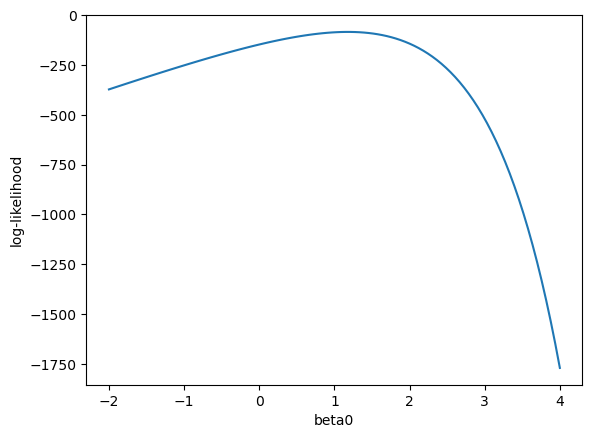

In [78]:
beta0_seq = np.linspace(-2, 4, 100)

log_likelihood = [
    np.sum(stats.poisson.logpmf(Y, mu=np.exp(b0)))
    for b0 in beta0_seq
]

plt.plot(beta0_seq, log_likelihood)
plt.xlabel("beta0")
plt.ylabel("log-likelihood")
plt.show()

# <font color='lightblue'> Example 2: Florida House Prices </font>

> Connections

In 


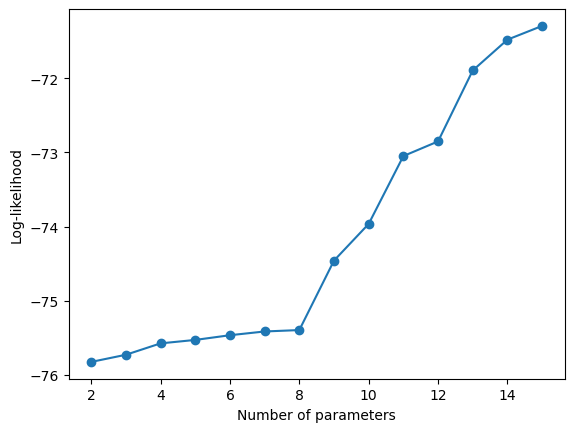

In [86]:
max_p = 14  # max polynomial degree
log_likelihoods = []
n_params = []

for p in range(1, max_p + 1):
    # build formula like: Y ~ X + X^2 + X^3 ...
    terms = " + ".join([f"np.power(X, {i})" for i in range(1, p + 1)])
    formula = "Y ~ " + terms

    model = smf.glm(formula=formula, data=Synthetic_df,
                    family=sm.families.Poisson()).fit()

    log_likelihoods.append(model.llf)
    n_params.append(model.df_model + 1)  # +1 for intercept

plt.plot(n_params, log_likelihoods, marker='o')
plt.xlabel("Number of parameters")
plt.ylabel("Log-likelihood")
plt.show()

# Further References

1. [Chapter 4:](https://download.e-bookshelf.de/download/0003/0821/70/L-G-0003082170-0005968026.pdf) Foundations of Linear and Generalized Linear Models
2. ???